In [1]:
import sys
sys.path.append('/Users/pa/Local Documents/GitHub Repositories/Spellbook')

In [18]:
import polars as pl
from spellbook.viz import plots, wordcloud
from datetime import date

In [3]:
post_path = '/Users/pa/Local Documents/GitHub Repositories/SiteScrape/SiteScrape/facebook_outputs/Krungthai Care/DB_Krungthai Care_Posts.csv'
comment_path = '/Users/pa/Local Documents/GitHub Repositories/SiteScrape/SiteScrape/facebook_outputs/Krungthai Care/DB_Krungthai Care_Comments.csv'

schemas = {
    'timestamp': pl.Datetime
}

post_df = pl.read_csv(post_path, schema_overrides=schemas)
comment_df = pl.read_csv(comment_path, schema_overrides=schemas)

# Date Range
start_date = date(2025, 7, 1)
end_date = date(2025, 10, 1)

post_df = post_df.filter(pl.col('timestamp').is_between(start_date, end_date))
comment_df = comment_df.filter(pl.col('timestamp').is_between(start_date, end_date))

In [4]:
post_df

source_id,timestamp,text,n_comment,url
str,datetime[μs],str,i64,str
"""post_e2cadbfd6da7bb7b08d2eb613…",2025-09-30 22:00:00,"""ประกาศรายชื่อผู้โชคดีกิจกรรม W…",35,"""https://www.facebook.com/krung…"
"""post_bdc07adb2c38a84a2ab596901…",2025-09-30 20:30:00,"""พิเศษ!! รับ-ส่งเงิน Western Un…",13,"""https://www.facebook.com/krung…"
"""post_72baf64b9610c89db58d53e20…",2025-09-29 20:30:00,"""สงครามการค้าระลอกใหม่ ไทยสู่ไม…",253,"""https://www.facebook.com/krung…"
"""post_0b8b1bfc33fcd4204ba5c850d…",2025-09-29 18:30:00,"""หลังไทยถูกสหรัฐฯ เก็บภาษีตอบโต…",7,"""https://www.facebook.com/krung…"
"""post_7e63eb6d3b654f734b9b37084…",2025-09-29 17:00:00,"""พร้อมดูแลอนาคตคนที่คุณห่วงใย …",388,"""https://www.facebook.com/krung…"
…,…,…,…,…
"""post_10bb983590cdb451f3f482ec2…",2025-07-02 12:00:00,"""พอกันทีกับคำว่าดีเกินไป! ถ้าเค…",14,"""https://www.facebook.com/krung…"
"""post_5e234b888a40546bbe882bb90…",2025-07-02 10:00:00,"""Krungthai x Maybank Securities…",0,"""https://www.facebook.com/krung…"
"""post_9d964abb16ce2ba808ba65ade…",2025-07-01 12:00:00,"""ใช้ชีวิตแบบ “ALIVE” ด้วยอิสระท…",41,"""https://www.facebook.com/krung…"


In [5]:
post_preprocess = post_df.with_columns(
    pl.col('timestamp').dt.date().alias('date')
)

In [6]:
post_preprocess.head()

source_id,timestamp,text,n_comment,url,date
str,datetime[μs],str,i64,str,date
"""post_e2cadbfd6da7bb7b08d2eb613…",2025-09-30 22:00:00,"""ประกาศรายชื่อผู้โชคดีกิจกรรม W…",35,"""https://www.facebook.com/krung…",2025-09-30
"""post_bdc07adb2c38a84a2ab596901…",2025-09-30 20:30:00,"""พิเศษ!! รับ-ส่งเงิน Western Un…",13,"""https://www.facebook.com/krung…",2025-09-30
"""post_72baf64b9610c89db58d53e20…",2025-09-29 20:30:00,"""สงครามการค้าระลอกใหม่ ไทยสู่ไม…",253,"""https://www.facebook.com/krung…",2025-09-29
"""post_0b8b1bfc33fcd4204ba5c850d…",2025-09-29 18:30:00,"""หลังไทยถูกสหรัฐฯ เก็บภาษีตอบโต…",7,"""https://www.facebook.com/krung…",2025-09-29
"""post_7e63eb6d3b654f734b9b37084…",2025-09-29 17:00:00,"""พร้อมดูแลอนาคตคนที่คุณห่วงใย …",388,"""https://www.facebook.com/krung…",2025-09-29


In [7]:
post_preprocess.group_by('date').agg(pl.col('n_comment').sum())

date,n_comment
date,i64
2025-09-27,988
2025-08-04,20
2025-08-05,17
2025-07-29,18
2025-08-31,278
…,…
2025-07-26,114
2025-08-09,160
2025-09-29,2294


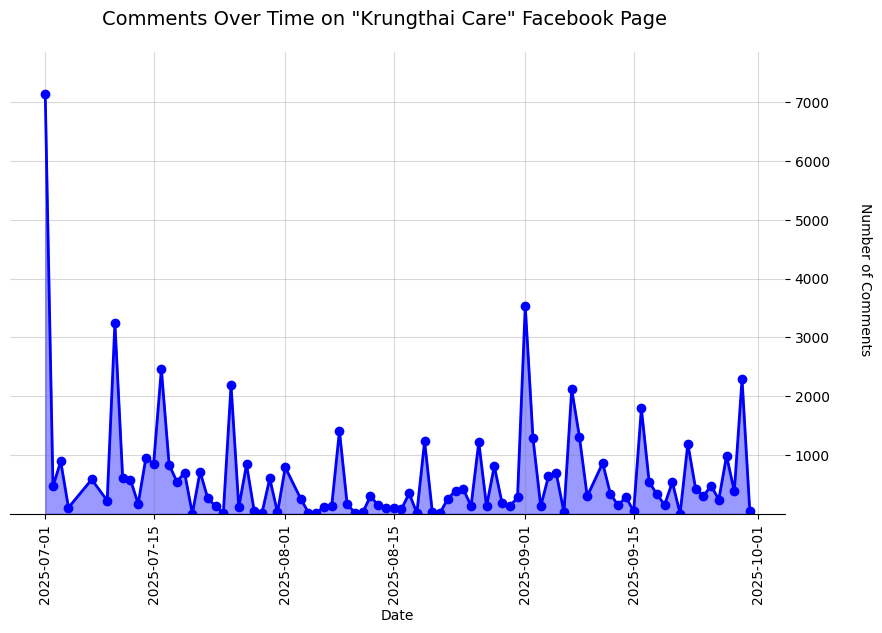

In [8]:
post_n_comment_groupby = post_preprocess.group_by('date').agg(pl.col('n_comment').sum())
date_groupby = post_n_comment_groupby.get_column('date')
n_comment = post_n_comment_groupby.get_column('n_comment')

plots.plot_data_over_time(
    x_data=date_groupby,
    y_data=n_comment,
    title='Comments Over Time on "Krungthai Care" Facebook Page',
    x_label='Date',
    y_label='Number of Comments',
    display_peak_number_annotation=False,
    y_label_pos=(0.98, 0.5),
    colors=['blue'],
    )

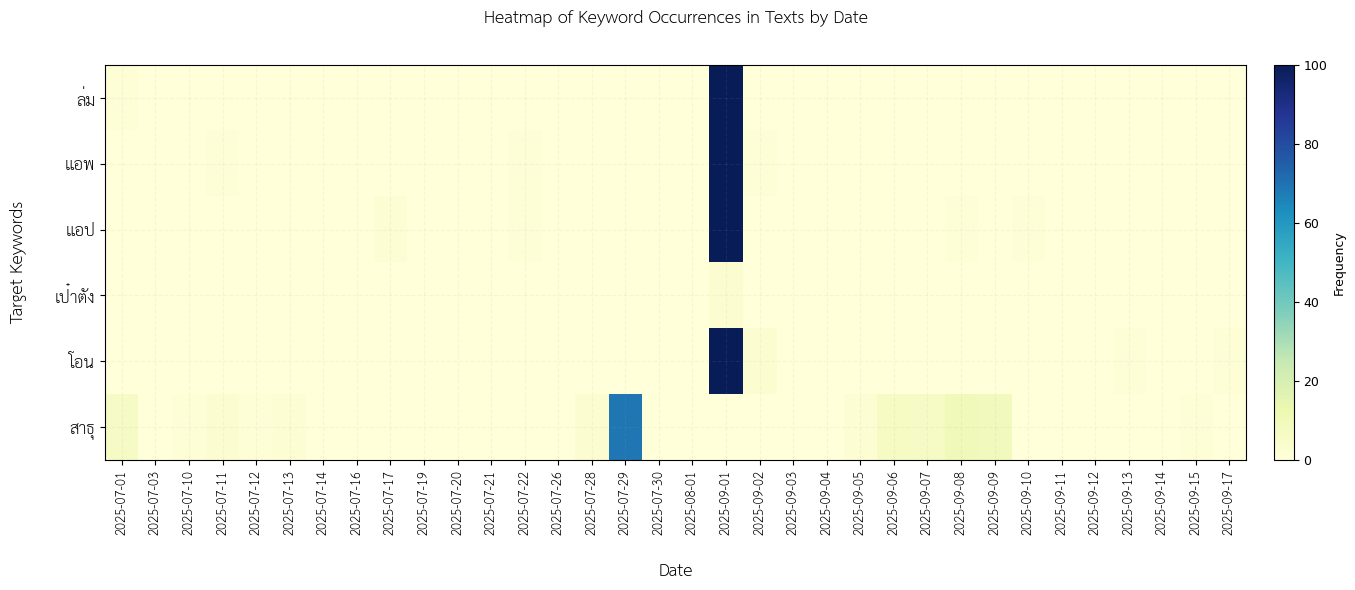

In [15]:
date = comment_df.get_column('timestamp')
texts = comment_df.get_column('text')
target_keywords = ['ล่ม', 'แอพ', 'แอป', 'เป๋าตัง', 'โอน', 'สาธุ']

plots.plot_keyword_heatmap(
    timestamps=date,
    texts=texts,
    target_keywords=target_keywords,
    fontpath='/Users/pa/Local Documents/GitHub Repositories/Spellbook/spellbook/viz/fonts/THSarabunNew.ttf',
    time_tick='date',
    axis_fontsize=18,
    max_y_scale=100,
    figsize=(15, 6)
)

In [22]:
comment_df

source_id,comment_id,timestamp,text,url
str,i64,datetime[μs],str,str
"""post_d52abd8eb2c9fc30179005f1b…",1906439903259905,2025-09-10 14:16:00,"""เทรนด์คอนเทนต์ที่ต้องตามให้ทัน…","""https://www.facebook.com/krung…"
"""post_d52abd8eb2c9fc30179005f1b…",735329349469389,2025-09-10 14:16:00,"""สำหรับคนที่อยากเริ่มต้นทำธุรกิ…","""https://www.facebook.com/krung…"
"""post_d52abd8eb2c9fc30179005f1b…",1273788150625295,2025-09-12 09:15:00,"""ขอถามค่ะการที่เราถือสมุดไปเบิก…","""https://www.facebook.com/krung…"
"""post_d52abd8eb2c9fc30179005f1b…",1829845507944399,2025-09-17 04:01:00,"""สอบถามคะ เปิดบัญชี เวลาโอนเงิน…","""https://www.facebook.com/krung…"
"""post_d52abd8eb2c9fc30179005f1b…",2734540600069164,2025-09-12 04:59:00,"""สุ้ๆครับคนเก่งกะด้อ""","""https://www.facebook.com/krung…"
…,…,…,…,…
"""post_0a99a9d8c21f65972e7dac428…",696903673247898,2025-07-01 08:45:00,"""ขอให้เฮงๆ ปังๆจ้า""","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1300738965033747,2025-07-01 07:40:00,"""สาธุค่ะ""","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1397787934671226,2025-07-01 08:01:00,"""สาธุค่ะ""","""https://www.facebook.com/krung…"


In [29]:
comment_df.filter(pl.col('timestamp').is_between(date(2025, 7, 1), date(2025, 7, 2)))

source_id,comment_id,timestamp,text,url
str,i64,datetime[μs],str,str
"""post_0a99a9d8c21f65972e7dac428…",1246734010436385,2025-07-01 13:08:00,"""วันนี้ไปทำแอบไม่ได้พนักงานให้ม…","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",648217808238392,2025-07-01 01:57:00,"""ทำไหมต้องค่าทำเนียมเวลากดเงินอ…","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1076483657746018,2025-07-01 09:56:00,"""ทำไมดูสลีปย้อนหลังไม่ได้ครับ ป…","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1085795133484647,2025-07-01 20:19:00,"""ระบบล่มไหมคะตอนนี้""","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1188138213001221,2025-07-01 10:42:00,"""why the government and Krung t…","""https://www.facebook.com/krung…"
…,…,…,…,…
"""post_0a99a9d8c21f65972e7dac428…",696903673247898,2025-07-01 08:45:00,"""ขอให้เฮงๆ ปังๆจ้า""","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1300738965033747,2025-07-01 07:40:00,"""สาธุค่ะ""","""https://www.facebook.com/krung…"
"""post_0a99a9d8c21f65972e7dac428…",1397787934671226,2025-07-01 08:01:00,"""สาธุค่ะ""","""https://www.facebook.com/krung…"


In [34]:
comment_df.filter(pl.col('timestamp').is_between(date(2025, 7, 1), date(2025, 7, 2))).get_column('text')

text
str
"""วันนี้ไปทำแอบไม่ได้พนักงานให้ม…"
"""ทำไหมต้องค่าทำเนียมเวลากดเงินอ…"
"""ทำไมดูสลีปย้อนหลังไม่ได้ครับ ป…"
"""ระบบล่มไหมคะตอนนี้"""
"""why the government and Krung t…"
…
"""ขอให้เฮงๆ ปังๆจ้า"""
"""สาธุค่ะ"""
"""สาธุค่ะ"""


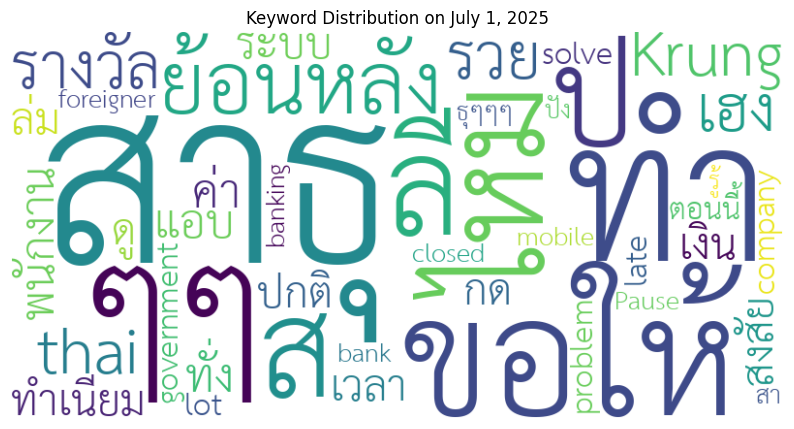

In [54]:
# 2025-07-01
text_list = comment_df.filter(pl.col('timestamp').is_between(date(2025, 7, 1), date(2025, 7, 2))).get_column('text')
texts = ' '.join(text_list)
wordcloud.plot_wordcloud(
    texts,
    keep_stopwords=False,
    background_color='white',
    title='Keyword Distribution on July 1, 2025'
    )

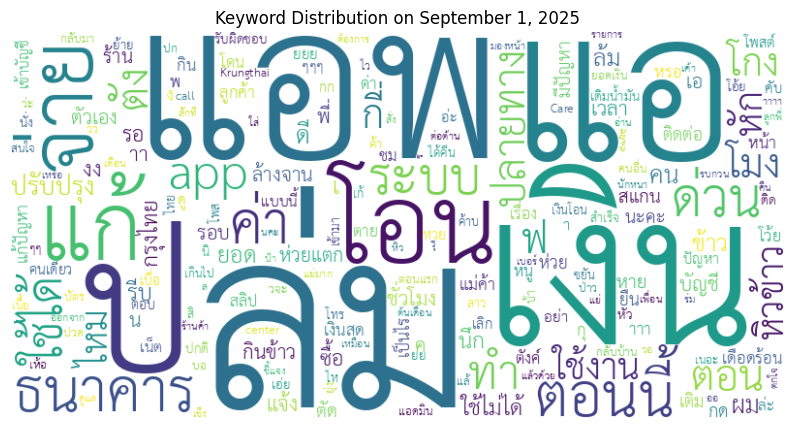

In [55]:
# 2025-09-01
text_list = comment_df.filter(pl.col('timestamp').is_between(date(2025, 9, 1), date(2025, 9, 2))).get_column('text')
texts = ' '.join(text_list)
wordcloud.plot_wordcloud(
    texts,
    keep_stopwords=False,
    background_color='white',
    title='Keyword Distribution on September 1, 2025'
    )

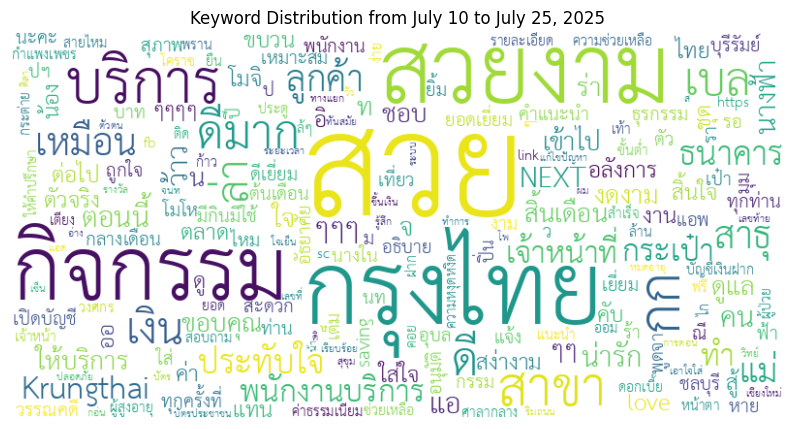

In [61]:
# 2025-07-10 - 2025-07-25
text_list = comment_df.filter(pl.col('timestamp').is_between(date(2025, 7, 10), date(2025, 7, 26))).get_column('text')
texts = ' '.join(text_list)
wordcloud.plot_wordcloud(
    texts,
    keep_stopwords=False,
    background_color='white',
    title='Keyword Distribution from July 10 to July 25, 2025'
    )

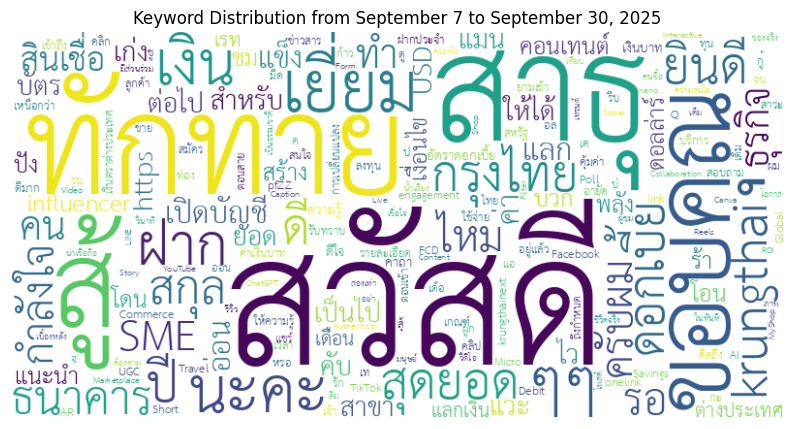

In [60]:
# 2025-9-7 - 2025-9-30
text_list = comment_df.filter(pl.col('timestamp').is_between(date(2025, 9, 7), date(2025, 10, 1))).get_column('text')
texts = ' '.join(text_list)
wordcloud.plot_wordcloud(
    texts,
    keep_stopwords=False,
    background_color='white',
    title='Keyword Distribution from September 7 to September 30, 2025'
    )

In [ ]:
# Save dataframe
#post_df.write_excel('Q3_KrungthaiCare_FB_Posts.xlsx')
#comment_df.write_excel('Q3_KrungthaiCare_FB_Comments_>1000.xlsx')